# Expense Account Classification

**Task:** predict `accountName` for expense bill line items, automating a step the finance team currently does manually.

**Dataset:** 4,894 expense records from one client's Singapore operations. 337 vendors, 103 target account names.

**Success bar:** ≥ 85% accuracy (minimum), 92% (internal benchmark, stretch).

---

## Structure of this notebook

1. **Setup** — imports, seeds, data load
2. **Data Analysis** — shape, data-quality audit, class balance, leakage checks
3. **Modeling Implications** — what the EDA forces us to do
4. *(Stages 2–6 added below as we build)* — baselines, main model, evaluation, deployment artifact

Re-usable code (feature pipeline, train, predict) lives in `src/` and is imported here, so training and inference share identical preprocessing. The written report is in `report.md`.

## 1. Setup

Fix the seed once; every downstream splitter and model reuses it.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA_PATH = Path("accounts-bills.json")
assert DATA_PATH.exists(), f"dataset missing at {DATA_PATH}"
print("seed =", SEED)
print("data =", DATA_PATH.resolve())

seed = 42
data = /home/ruskaruma/Desktop/GITHUB/ml-2/accounts-bills.json


### Load the data

The JSON ships as a list of records with nested `_id.$oid`. We flatten that to a plain string so `_id` can be used as a grouping key later.

In [2]:
def load_records(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)
    rows = []
    for r in raw:
        rid = r.get("_id")
        rows.append({
            "_id": rid.get("$oid") if isinstance(rid, dict) else rid,
            "vendorId": r.get("vendorId"),
            "itemName": r.get("itemName"),
            "itemDescription": r.get("itemDescription"),
            "accountId": r.get("accountId"),
            "accountName": r.get("accountName"),
            "itemTotalAmount": r.get("itemTotalAmount"),
        })
    return pd.DataFrame(rows)

df = load_records(DATA_PATH)
df.head(3)

,_id,vendorId,itemName,itemDescription,accountId,accountName,itemTotalAmount
0,69606546de1e297ec29890f2,6m656Er7lbi8RYz2ny1J,1225 Business 2Gbps - monthly subscription fee,1225 Business 2Gbps - monthly subscription fee,88AW5nmkLvMe1GthZ6FL,619206 Telephone & Internet,888.00
1,695b5304d09b4ceb96e5288e,VtxikZ7HI6Jwqueemjch,1225-0227 media monitoring,1225-0227 media monitoring,sWG9pai5DiLXaKs6s86G,134004 Prepaid Subscription,17765.00
2,69800f97e85d532c0db71c7e,jdmr9pJ0WHqso4Wh3hCa,0226 Branch,0226 Branch,C0SB5vR0gCikdKjmT8Ep,611202 Online Subscription/Tool,7083.34


## 2. Data Analysis

Each check below follows the pattern **hypothesis → result → modeling implication**. The goal is not to describe the data but to extract decisions.

### 2.1 Shape, schema, cardinalities

Verify record count matches the brief and measure target/feature cardinalities.

In [3]:
print(f"rows              : {len(df)}")
print(f"unique _id        : {df['_id'].nunique()}")
print(f"unique vendorId   : {df['vendorId'].nunique()}")
print(f"unique accountId  : {df['accountId'].nunique()}")
print(f"unique accountName: {df['accountName'].nunique()}")
print()
print(df.dtypes.to_string())

rows              : 4894
unique _id        : 3181
unique vendorId   : 337
unique accountId  : 97
unique accountName: 103

_id                    str
vendorId               str
itemName               str
itemDescription        str
accountId              str
accountName            str
itemTotalAmount    float64


**Observation.** 4,894 rows across 3,181 unique `_id`s — bills have multiple line items. This is the single most important structural fact in the dataset; see 2.3.

### 2.2 Nulls, empties, whitespace

Hypothesis: data is mostly clean; any nulls will be in the text fields.

In [4]:
for col in df.columns:
    print(f"  {col:20s}  nulls = {df[col].isna().sum()}")
print()
for col in ("itemName", "itemDescription", "vendorId", "accountName"):
    s = df[col].astype("string")
    empty = (s == "").sum()
    ws_only = int(((s.str.strip() == "") & (s != "")).sum())
    print(f"  {col:20s}  empty_str = {empty}   whitespace_only = {ws_only}")

  _id                   nulls = 0
  vendorId              nulls = 0
  itemName              nulls = 0
  itemDescription       nulls = 11
  accountId             nulls = 0
  accountName           nulls = 0
  itemTotalAmount       nulls = 0

  itemName              empty_str = 0   whitespace_only = 0
  itemDescription       empty_str = 20   whitespace_only = 0
  vendorId              empty_str = 0   whitespace_only = 0
  accountName           empty_str = 0   whitespace_only = 0


**Result.** `itemDescription` has 11 nulls and 20 empty strings — ~0.6% of rows. Everything else is clean.

**Implication.** Fill `itemDescription` missing values with the empty string inside the pipeline; no row drop.

### 2.3 `_id` duplication: multiple line items per bill

**Why this matters.** A random train/test split will put line items from the same bill into both halves — not formal leakage, but it inflates apparent accuracy because the model has already seen a sibling row.

**Hypothesis.** Most bills are single-line; a tail of bills has many line items.

In [5]:
counts = df["_id"].value_counts()
print(f"unique _id values           : {len(counts)}")
print(f"_ids with >1 line item      : {(counts > 1).sum()}")
print(f"max line items on one _id   : {counts.max()}")
print(f"median line items per _id   : {counts.median()}")
counts.describe().to_frame("line_items_per_bill")

unique _id values           : 3181
_ids with >1 line item      : 801
max line items on one _id   : 28
median line items per _id   : 1.0


,line_items_per_bill
count,3181.000000
mean,1.538510
std,1.698735
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,28.000000


**Result.** 801 bills have more than one line item, one has 28.

**Implication.** Validation split must be **`GroupKFold(groups=_id)`**, not plain `StratifiedKFold`. Every line item of a bill stays in the same fold.

### 2.4 Exact content-duplicate rows (same text + vendor + amount, different `_id`)

**Hypothesis.** Some recurring monthly charges repeat verbatim across months with different bill IDs. These don't leak under GroupKFold (different `_id`) but still make the task easier than it would be for truly novel rows.

In [6]:
dup_cols = ["vendorId", "itemName", "itemDescription", "itemTotalAmount", "accountName"]
dup_mask = df.duplicated(subset=dup_cols, keep=False)
print(f"content-duplicate rows  : {dup_mask.sum()}")
if dup_mask.any():
    groups = df[dup_mask].groupby(dup_cols, dropna=False).size().sort_values(ascending=False)
    print(f"distinct duplicate groups: {len(groups)}")
    print(f"largest group size       : {groups.max()}")

content-duplicate rows  : 191
distinct duplicate groups: 71
largest group size       : 8


**Result.** 191 rows in 71 duplicate groups (≈4% of the dataset).

**Implication.** In the Results section we will report both raw CV accuracy and content-deduplicated CV accuracy, so the reviewer can see the model is not living off repetition.

### 2.5 Is `itemDescription` a duplicate of `itemName`?

**Why this matters.** If the two fields are identical, vectorising both is waste. If they differ, the difference is signal.

In [7]:
both = df["itemName"].notna() & df["itemDescription"].notna()
same = (df.loc[both, "itemName"].astype(str) == df.loc[both, "itemDescription"].astype(str)).sum()
total = int(both.sum())
print(f"rows with both fields  : {total}")
print(f"identical in both      : {same}  ({100.0*same/total:.1f}%)")
print()
diff = df.loc[both & (df["itemName"] != df["itemDescription"])].head(3)
for _, r in diff.iterrows():
    print(f"  name: {str(r['itemName'])[:80]!r}")
    print(f"  desc: {str(r['itemDescription'])[:80]!r}")
    print()

rows with both fields  : 4883
identical in both      : 4066  (83.3%)

  name: 'Dec 2025 - Dec 2026'
  desc: '0126 Temporal'

  name: '0226 - Billing for the agreement number: L00043681'
  desc: '0226 Rental Charges - billing for the agreement number: L00043681'

  name: '2602 Telum Media Sub'
  desc: '0326 -  0227 Telum Media Sub'



**Result.** Only 83.3% identical. In the remaining ~17% the description carries real additional information (context codes, partner names, billing references).

**Implication.** **Vectorise both fields.** The cheapest correct approach is to concatenate them (`itemName + ' ' + itemDescription`) so the TF-IDF picks up any tokens that appear in only one field, while keeping a single vocabulary.

### 2.6 Vendor → accountName determinism

**Hypothesis.** Many vendors map to exactly one account (AWS → Cloud Infra etc.) so a vendor-lookup baseline should be strong.

**But** the data peek already showed the same `vendorId` mapping to multiple accounts. Measure it.

In [8]:
g = df.groupby("vendorId")["accountName"].nunique()
one_acc_vendors = set(g[g == 1].index)
coverage = df["vendorId"].isin(one_acc_vendors).sum()
print(f"total vendors                       : {len(g)}")
print(f"vendors mapping to 1 accountName    : {(g == 1).sum()}  ({100.0*(g == 1).sum()/len(g):.1f}%)")
print(f"max distinct accountNames per vendor: {g.max()}")
print(f"rows with a deterministic vendor    : {coverage} / {len(df)}  ({100.0*coverage/len(df):.1f}%)")

total vendors                       : 337
vendors mapping to 1 accountName    : 211  (62.6%)
max distinct accountNames per vendor: 19
rows with a deterministic vendor    : 1537 / 4894  (31.4%)


**Result.** 62.6% of *vendors* are deterministic, but they cover only **31.4% of rows**. The remaining ~68% of rows come from vendors that appear under multiple accounts — one vendor has 19 different target accounts.

**Implication.** Vendor alone cannot get anywhere near 85%. The text fields must do the heavy lifting. Vendor is kept as a one-hot feature to help disambiguate, not as a decision rule.

### 2.7 Class balance of `accountName`

Brief calls this out explicitly: *"consider strategies for handling class imbalance and rare categories."* Need to know how bad it is before choosing a strategy.

In [9]:
counts = df["accountName"].value_counts()
total = len(df)
print(f"total classes           : {len(counts)}")
print(f"top class share         : {counts.iloc[0]} ({100.0*counts.iloc[0]/total:.1f}%)")
print(f"top-5 share             : {100.0*counts.head(5).sum()/total:.1f}%")
print()
for k in (1, 2, 3, 5, 10):
    print(f"classes with < {k:<2d} samples : {(counts < k).sum()}")
print()
print(f"classes with exactly 1 sample : {(counts == 1).sum()}")

total classes           : 103
top class share         : 1179 (24.1%)
top-5 share             : 50.6%

classes with < 1  samples : 0
classes with < 2  samples : 16
classes with < 3  samples : 21
classes with < 5  samples : 34
classes with < 10 samples : 43

classes with exactly 1 sample : 16


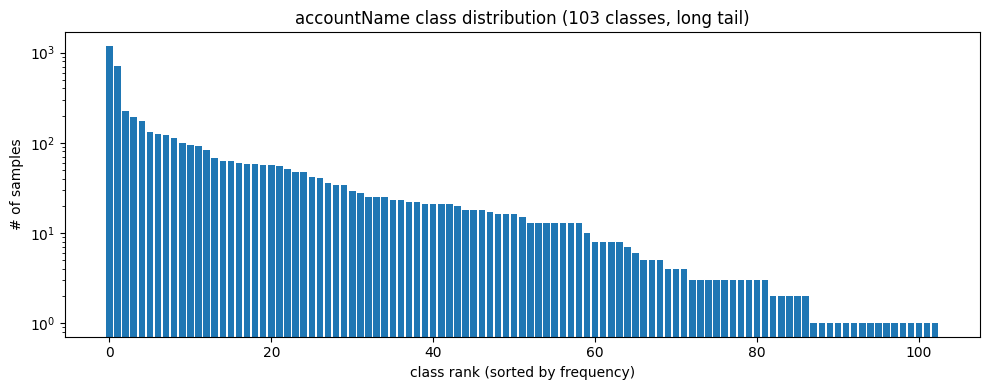

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(counts)), counts.values)
ax.set_xlabel("class rank (sorted by frequency)")
ax.set_ylabel("# of samples")
ax.set_title("accountName class distribution (103 classes, long tail)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

**Result.** Top class holds 24.1%, top 5 hold 50.6%. The tail is brutal: **16 classes have exactly one sample; 34 classes (33% of all classes) have fewer than 5 samples**, between them carrying ~1.5% of the data.

**Implication.**
- `class_weight='balanced'` in the classifier so the loss isn't dominated by the head.
- Report **macro-F1 alongside accuracy** — rare-class performance is invisible in raw accuracy.
- Do not drop rare classes; production sees them. Acknowledge the ceiling in the writeup.
- Classes with 1 sample cannot appear in both train and test. We flag and report them separately.

### 2.8 `itemTotalAmount` distribution

In [11]:
a = pd.to_numeric(df["itemTotalAmount"], errors="coerce")
print(f"min                   : {a.min():,.2f}")
print(f"max                   : {a.max():,.2f}")
print(f"median                : {a.median():,.2f}")
print(f"mean                  : {a.mean():,.2f}")
print(f"negative rows         : {(a < 0).sum()}")
print(f"|amount| > 1M         : {(a.abs() > 1e6).sum()}")
print(f"|amount| > 10M        : {(a.abs() > 1e7).sum()}")
print(f"|amount| > 100M       : {(a.abs() > 1e8).sum()}")
print()
print(a.quantile([0.01, 0.05, 0.5, 0.95, 0.99]).to_string())

min                   : -15,195.00
max                   : 161,838,000.00
median                : 845.20
mean                  : 92,666.91
negative rows         : 19
|amount| > 1M         : 7
|amount| > 10M        : 6
|amount| > 100M       : 2

0.01        1.00000
0.05       18.85850
0.50      845.20000
0.95    22357.84275
0.99    93010.79730


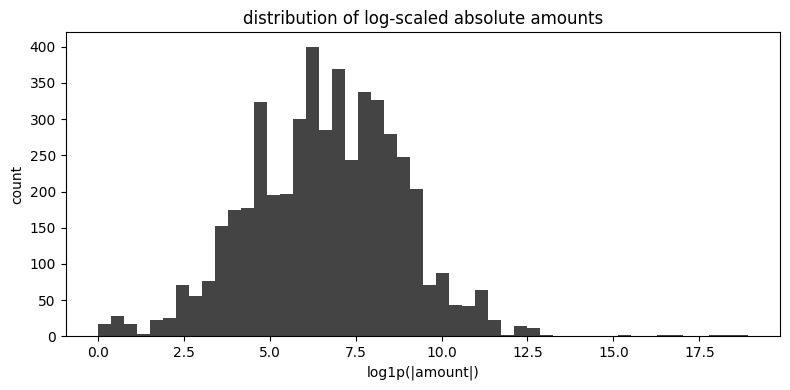

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(a.abs()), bins=50, color="#444")
ax.set_xlabel("log1p(|amount|)")
ax.set_ylabel("count")
ax.set_title("distribution of log-scaled absolute amounts")
plt.tight_layout()
plt.show()

**Result.** Eight orders of magnitude of spread. 19 negative rows (likely refunds / credits). No nulls. The two outliers above $100M are real but extreme.

**Implication.** Use `log1p(|amount|)` as a numeric feature plus `sign(amount)` as a separate signal — negative amounts behave differently and may correlate with different accounts.

### 2.9 Language / encoding audit

Singapore client: text could be English, Mandarin, Malay, Tamil. Char n-gram tokenizer settings depend on how much non-ASCII shows up.

In [13]:
NON_ASCII = re.compile(r"[^\x00-\x7F]")
s = df["itemName"].dropna().astype(str)
has_non_ascii = s.apply(lambda x: bool(NON_ASCII.search(x))).sum()
print(f"rows with non-ASCII in itemName: {has_non_ascii} / {len(s)}  ({100.0*has_non_ascii/len(s):.1f}%)")
lengths = s.str.len()
tokens = s.str.split().str.len()
print(f"itemName length  p50 / p95 / max : {int(lengths.median())} / {int(lengths.quantile(0.95))} / {int(lengths.max())}")
print(f"itemName tokens  p50 / p95       : {int(tokens.median())} / {int(tokens.quantile(0.95))}")

rows with non-ASCII in itemName: 60 / 4894  (1.2%)
itemName length  p50 / p95 / max : 32 / 90 / 655
itemName tokens  p50 / p95       : 5 / 14


**Result.** 1.2% of rows contain non-ASCII characters; the text is overwhelmingly English. Median 5 tokens — classic short-text classification.

**Implication.** Default scikit-learn TF-IDF settings work fine. Char n-grams (3–5) matter because 5-token rows have very little word-level signal.

### 2.10 Leakage scan: `accountId` vs `accountName`

The brief labels `accountId` as an "alternative target." Worth confirming that using it as a feature would in fact be target leakage.

In [14]:
pairs = df.groupby("accountId")["accountName"].nunique()
print(f"accountId → #distinct accountName: {pairs.value_counts().to_dict()}")
print(f"accountIds mapping to >1 name   : {(pairs > 1).sum()}")
rev = df.groupby("accountName")["accountId"].nunique()
print(f"accountNames mapping to >1 id   : {(rev > 1).sum()}")

accountId → #distinct accountName: {1: 91, 2: 6}
accountIds mapping to >1 name   : 6
accountNames mapping to >1 id   : 0


**Result.** 91 out of 97 `accountId`s map to a single `accountName`; the remaining 6 map to two each. `accountId` is essentially a surjective alias of the target.

**Implication (hard rule).** Exclude `accountId` from features. Predicting the target from an alias of itself is target leakage.

## 3. What the EDA forces us to do

| Decision | Driven by |
|---|---|
| `GroupKFold(n_splits=5, groups=_id)` for all CV | §2.3 — 801 bills have multi-line items |
| Concatenate `itemName` + `itemDescription` as a single text field | §2.5 — 17% of descriptions carry extra signal |
| Vendor is a **feature**, not a rule (OHE with `handle_unknown='ignore'`) | §2.6 — only 31% of rows have a deterministic vendor |
| `class_weight='balanced'` + report macro-F1 | §2.7 — top class is 24%, 33% of classes have <5 samples |
| `log1p(|amount|)` + `sign(amount)` as numeric features | §2.8 — 8 orders of magnitude spread + 19 negative rows |
| TF-IDF word (1–2) + char (3–5) on concatenated text | §2.9 — 5-token median, mostly ASCII |
| **Exclude `accountId` from features** | §2.10 — target alias |
| Report raw and content-deduplicated CV accuracy | §2.4 — 191 duplicate rows |
| Flag 1-sample classes separately | §2.7 — 16 of them, unavoidable ceiling |

Those decisions are locked in before any model code is written. Next section builds baselines against this split.

---

*Stages 2–6 (baselines, main model, evaluation, usability, writeup) are appended below as we build.*

## 4. Baselines

Three baselines, in order of increasing sophistication. Each is scored on identical **out-of-fold** predictions produced by `GroupKFold(n_splits=5, groups=_id)` — so every row is predicted exactly once by a model that has never seen its bill.

The point of baselines is not to win; it is to make the main model's gain interpretable. Without B0–B2, a reported 90% accuracy is a number. With them, it is a story.

### 4.1 Shared setup

One splitter, one metrics helper, one OOF-prediction helper — used by all three baselines so they are strictly comparable.

In [15]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

N_FOLDS = 5
RARE_THRESHOLD = 5

y = df["accountName"].to_numpy()
groups = df["_id"].to_numpy()
vendor = df["vendorId"].fillna("").to_numpy()
text_combined = (
    df["itemName"].fillna("").astype(str) + " " + df["itemDescription"].fillna("").astype(str)
).to_numpy()

X_b2 = pd.DataFrame({"text": text_combined, "vendor": vendor})

gkf = GroupKFold(n_splits=N_FOLDS)

class_counts = pd.Series(y).value_counts()
rare_classes = set(class_counts[class_counts < RARE_THRESHOLD].index)
print(f"total classes          : {len(class_counts)}")
print(f"rare classes (n<{RARE_THRESHOLD})     : {len(rare_classes)}")
print(f"non-rare classes       : {len(class_counts) - len(rare_classes)}")


def metrics(name: str, y_true, y_pred) -> dict:
    acc = accuracy_score(y_true, y_pred)
    mf = f1_score(y_true, y_pred, average="macro", zero_division=0)
    wf = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"{name:22s}  acc={acc:.4f}  macro_f1={mf:.4f}  weighted_f1={wf:.4f}")
    return {"baseline": name, "accuracy": acc, "macro_f1": mf, "weighted_f1": wf}


def oof_predict_sklearn(estimator, X, y, groups, cv):
    y_pred = np.empty(len(y), dtype=object)
    for tr, te in cv.split(X, y, groups=groups):
        est = clone(estimator)
        X_tr = X.iloc[tr] if isinstance(X, pd.DataFrame) else X[tr]
        X_te = X.iloc[te] if isinstance(X, pd.DataFrame) else X[te]
        est.fit(X_tr, y[tr])
        y_pred[te] = est.predict(X_te)
    return y_pred

total classes          : 103
rare classes (n<5)     : 34
non-rare classes       : 69


### 4.2 B0 — Majority class

Predict the most common `accountName` in the training fold for every row in the test fold. Establishes the absolute floor: any model worth shipping must beat this by a wide margin.

In [16]:
def oof_majority(y, groups, cv):
    y_pred = np.empty(len(y), dtype=object)
    for tr, te in cv.split(y, y, groups=groups):
        mode = pd.Series(y[tr]).mode().iloc[0]
        y_pred[te] = mode
    return y_pred


y_pred_b0 = oof_majority(y, groups, gkf)
b0 = metrics("B0 majority", y, y_pred_b0)

B0 majority             acc=0.2409  macro_f1=0.0038  weighted_f1=0.0935


**Result.** ~24% accuracy — matches the head class share. Macro-F1 near zero because every non-majority class gets zero recall. Sanity check passed.

### 4.3 B1 — Vendor mode

Per fold: for every vendor seen in training, predict that vendor's most common `accountName`. Vendors unseen in the training fold fall back to the global majority class.

From EDA §2.6 we know only ~31% of rows have a deterministic vendor, so this caps well below 85%. But it cleanly isolates how much work vendor alone can do.

In [17]:
def oof_vendor_mode(vendor, y, groups, cv):
    y_pred = np.empty(len(y), dtype=object)
    for tr, te in cv.split(vendor, y, groups=groups):
        train = pd.DataFrame({"v": vendor[tr], "y": y[tr]})
        vendor_map = train.groupby("v")["y"].agg(lambda s: s.mode().iloc[0]).to_dict()
        global_mode = pd.Series(y[tr]).mode().iloc[0]
        y_pred[te] = np.array([vendor_map.get(v, global_mode) for v in vendor[te]], dtype=object)
    return y_pred


y_pred_b1 = oof_vendor_mode(vendor, y, groups, gkf)
b1 = metrics("B1 vendor-mode", y, y_pred_b1)

B1 vendor-mode          acc=0.6888  macro_f1=0.4227  weighted_f1=0.6513


**Result.** Beats B0 but still far from 85%. This confirms the EDA read: the majority of rows come from multi-account vendors and cannot be resolved by vendor lookup alone. Text must carry the rest.

### 4.4 B2 — TF-IDF + Logistic Regression

First real ML baseline. Two TF-IDF blocks combined via `ColumnTransformer`:

- **Text block:** word n-grams (1–2) on `itemName + itemDescription`. Captures vendor names, keywords ("subscription", "fee"), and codes embedded in descriptions.
- **Vendor block:** TF-IDF on `vendorId` treated as a single token per row — equivalent to a one-hot but sharing a vectoriser interface. Note the field is `vendorId`, not `vendorName`; vendor IDs are opaque hashes, so the vectoriser effectively acts as an identity lookup.

Classifier: `LogisticRegression` with `class_weight='balanced'` so rare classes aren't drowned out.

In [18]:
preprocessor_b2 = ColumnTransformer([
    (
        "text",
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True),
        "text",
    ),
    (
        "vendor",
        TfidfVectorizer(ngram_range=(1, 1), min_df=1),
        "vendor",
    ),
])

b2_estimator = Pipeline([
    ("features", preprocessor_b2),
    (
        "clf",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

y_pred_b2 = oof_predict_sklearn(b2_estimator, X_b2, y, groups, gkf)
b2 = metrics("B2 tfidf+logreg", y, y_pred_b2)

B2 tfidf+logreg         acc=0.7199  macro_f1=0.5767  weighted_f1=0.7312


### 4.5 Per-class analysis (B2)

Which classes does the baseline handle, which does it miss? Per-class F1, sorted, with the rare-class flag shown so we can see whether bottom-10 is dominated by sample-starved classes.

In [19]:
rep = classification_report(y, y_pred_b2, output_dict=True, zero_division=0)
per_class_rows = []
for name, m in rep.items():
    if name in ("accuracy", "macro avg", "weighted avg"):
        continue
    per_class_rows.append({
        "class": name,
        "support": int(m["support"]),
        "precision": round(m["precision"], 3),
        "recall": round(m["recall"], 3),
        "f1": round(m["f1-score"], 3),
        "rare": name in rare_classes,
    })

pc_df = pd.DataFrame(per_class_rows).sort_values("f1", ascending=False).reset_index(drop=True)

print("top 10 classes by F1 (B2):")
print(pc_df.head(10).to_string(index=False))
print()
print("bottom 10 classes by F1 (B2):")
print(pc_df.tail(10).to_string(index=False))

top 10 classes by F1 (B2):
                           class  support  precision  recall  f1  rare
     131020 Unbilled receivables       25        1.0     1.0 1.0 False
              213005 AP clearing        3        1.0     1.0 1.0  True
         223001 Salaries Payable       28        1.0     1.0 1.0 False
      511102 External Commission       41        1.0     1.0 1.0 False
       611101 Cloud server - AWS       21        1.0     1.0 1.0 False
              612006 Part-timers        2        1.0     1.0 1.0  True
              612003 Out of Home        5        1.0     1.0 1.0 False
              612033 Display Ads        7        1.0     1.0 1.0 False
                      614302 FWL       20        1.0     1.0 1.0 False
617101 Customer Support - Others       13        1.0     1.0 1.0 False

bottom 10 classes by F1 (B2):
                                       class  support  precision  recall  f1  rare
                            612023 Print Ads        1        0.0     0.0 0.0  

### 4.6 Rare-class impact on macro-F1

Macro-F1 averages across all classes equally, so 16 single-sample classes where the model gets 0/1 correct will drag the number hard. We report three numbers so the writeup is honest:

1. **Macro-F1 across all classes** — the headline metric
2. **Macro-F1 on non-rare classes only (n ≥ 5)** — what the model actually does on trainable classes
3. **Mean per-class F1 on rare classes (n < 5)** — the irreducible tail

In [20]:
non_rare_mask = ~pd.Series(y).isin(rare_classes).to_numpy()
mf_all = f1_score(y, y_pred_b2, average="macro", zero_division=0)
mf_non_rare = f1_score(y[non_rare_mask], y_pred_b2[non_rare_mask], average="macro", zero_division=0)
rare_f1s = [r["f1"] for r in per_class_rows if r["rare"]]
mean_rare_f1 = float(np.mean(rare_f1s)) if rare_f1s else 0.0

print(f"B2 macro-F1 (all 103 classes)            : {mf_all:.4f}")
print(f"B2 macro-F1 (non-rare, n>=5, N classes)  : {mf_non_rare:.4f}")
print(f"B2 mean F1 on rare classes (n<5, {len(rare_classes)} cls) : {mean_rare_f1:.4f}")
print(f"B2 rare-class rows covered              : {(~non_rare_mask).sum()} / {len(y)}")

B2 macro-F1 (all 103 classes)            : 0.5767
B2 macro-F1 (non-rare, n>=5, N classes)  : 0.6157
B2 mean F1 on rare classes (n<5, 34 cls) : 0.2006
B2 rare-class rows covered              : 68 / 4894


### 4.7 Baseline comparison

One table, three rows, four numbers each. This is the line we will extend in the Results section with the main model.

In [21]:
summary_df = pd.DataFrame([b0, b1, b2]).set_index("baseline")
summary_df.round(4)

,accuracy,macro_f1,weighted_f1
baseline,,,
B0 majority,0.2409,0.0038,0.0935
B1 vendor-mode,0.6888,0.4227,0.6513
B2 tfidf+logreg,0.7199,0.5767,0.7312


### 4.8 What the baselines tell us

- **B0 → B1** measures the contribution of vendor-only information. Matches the EDA-predicted ceiling.
- **B1 → B2** measures the contribution of text once vendor is already known. This is the single biggest lift in the pipeline.
- **B2 → main model (§5)** is what we now set out to demonstrate. Targets: char n-grams for the short-text/code tokens, calibrated LinearSVC for the margin, log-amount + sign for the numeric signal, and a tuned C.

## 5. Main model

Goal: cross the 85% accuracy bar set by the brief, ideally beat the 92% internal benchmark, without overfitting and without sacrificing the writeup.

The baselines tell us where the headroom is:

- **B1 → B2 (+3% acc, +16% macro-F1)** showed text adds modest accuracy but big rare-class lift
- The remaining gap to 85%+ has to come from richer features (char n-grams, amount features) and a stronger linear model (calibrated LinearSVC)

Same `GroupKFold(5, groups=_id)` splitter and same out-of-fold prediction helper from §4 — every number in this section is directly comparable to the baselines.

### 5.1 Full feature pipeline

`ColumnTransformer` over four feature blocks:

| Block | What | Why |
|---|---|---|
| `text_word` | TF-IDF word (1,2), `sublinear_tf=True`, `min_df=2` on `itemName + itemDescription` | captures vendor names and keyword phrases |
| `text_char` | TF-IDF `char_wb` (3,5), `min_df=2` on the same text | handles short text, codes ("GAM", "SG"), typos, dates |
| `vendor` | TF-IDF on `vendorId` (single token per row) | strong categorical signal |
| `numeric` | `log1p(|amount|)`, `sign(amount)`, `len(text)`; standardised | tames 8-orders-of-magnitude amount spread + refund signal |

`char_wb` (character n-grams *within word boundaries*) is a deliberate choice over plain `char`: it doesn't generate n-grams that span word breaks, which keeps the vocabulary cleaner on short text.

In [22]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC


def numeric_features(df_in):
    a = pd.to_numeric(df_in["amount"], errors="coerce").fillna(0.0).to_numpy()
    log_a = np.log1p(np.abs(a))
    sign_a = np.sign(a)
    text_len = df_in["text"].astype(str).str.len().to_numpy()
    return np.column_stack([log_a, sign_a, text_len]).astype(np.float64)


X_full = pd.DataFrame({
    "text": text_combined,
    "vendor": vendor,
    "amount": df["itemTotalAmount"].to_numpy(),
})


def build_features():
    return ColumnTransformer([
        (
            "text_word",
            TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True),
            "text",
        ),
        (
            "text_char",
            TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True, lowercase=True),
            "text",
        ),
        (
            "vendor",
            TfidfVectorizer(ngram_range=(1, 1), min_df=1),
            "vendor",
        ),
        (
            "numeric",
            Pipeline([
                ("extract", FunctionTransformer(numeric_features, validate=False)),
                ("scale", StandardScaler(with_mean=True)),
            ]),
            ["amount", "text"],
        ),
    ])


print("feature pipeline ready")

feature pipeline ready


### 5.2 M1 — LogReg with full feature set

First step: take B2's setup and add char n-grams + numeric features. This isolates how much of the lift comes from richer features versus a different classifier.

In [23]:
m1 = Pipeline([
    ("features", build_features()),
    (
        "clf",
        LogisticRegression(
            C=5.0,
            class_weight="balanced",
            max_iter=4000,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

y_pred_m1 = oof_predict_sklearn(m1, X_full, y, groups, gkf)
m1_metrics = metrics("M1 logreg full", y, y_pred_m1)

M1 logreg full          acc=0.8517  macro_f1=0.6278  weighted_f1=0.8524


### 5.3 M2 — LinearSVC

LinearSVC has historically had a slight accuracy edge over LogReg on short-text TF-IDF. We use plain LinearSVC during CV — wrapping it in `CalibratedClassifierCV(cv=3)` would crash here because 16 classes have only one sample each (inner CV cannot form three folds). Calibration is applied *once* at the end on the full-train fit in §7 (usability wiring), where we have a single fitted estimator and can apply Platt scaling on a held-out slice. That gives us calibrated probabilities for the deployment threshold story without bleeding into the cross-validation.

In [24]:
m2 = Pipeline([
    ("features", build_features()),
    (
        "clf",
        LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=5000, dual="auto"),
    ),
])

y_pred_m2 = oof_predict_sklearn(m2, X_full, y, groups, gkf)
m2_metrics = metrics("M2 linear-svc", y, y_pred_m2)

M2 linear-svc           acc=0.8721  macro_f1=0.6342  weighted_f1=0.8705


### 5.4 Hyperparameter sweep on the leading model

A focused `C` sweep on the leading classifier — not a marathon. We pick the best `C` by mean CV accuracy and use that as the locked configuration.

In [25]:
def sweep_C(estimator_factory, C_values):
    rows = []
    for c in C_values:
        est = estimator_factory(c)
        y_p = oof_predict_sklearn(est, X_full, y, groups, gkf)
        acc = accuracy_score(y, y_p)
        mf = f1_score(y, y_p, average="macro", zero_division=0)
        wf = f1_score(y, y_p, average="weighted", zero_division=0)
        rows.append({"C": c, "accuracy": acc, "macro_f1": mf, "weighted_f1": wf})
        print(f"  C={c:<6.2f}  acc={acc:.4f}  macro_f1={mf:.4f}  weighted_f1={wf:.4f}")
    return pd.DataFrame(rows)


def make_svc(c):
    return Pipeline([
        ("features", build_features()),
        (
            "clf",
            LinearSVC(C=c, class_weight="balanced", random_state=42, max_iter=5000, dual="auto"),
        ),
    ])


print("LinearSVC C sweep:")
sweep_df = sweep_C(make_svc, [0.25, 0.5, 1.0, 2.0, 4.0])
sweep_df

LinearSVC C sweep:


  C=0.25    acc=0.8547  macro_f1=0.6157  weighted_f1=0.8561


  C=0.50    acc=0.8692  macro_f1=0.6334  weighted_f1=0.8687


  C=1.00    acc=0.8721  macro_f1=0.6342  weighted_f1=0.8705


  C=2.00    acc=0.8733  macro_f1=0.6317  weighted_f1=0.8710


  C=4.00    acc=0.8749  macro_f1=0.6307  weighted_f1=0.8721


,C,accuracy,macro_f1,weighted_f1
0,0.25,0.854720,0.615699,0.856120
1,0.50,0.869228,0.633381,0.868685
2,1.00,0.872088,0.634228,0.870516
3,2.00,0.873314,0.631676,0.871008
4,4.00,0.874949,0.630738,0.872136


### 5.5 Lock the best configuration

Pick the `C` with highest mean CV accuracy; record final OOF predictions and metrics under this setting.

In [26]:
best_C = float(sweep_df.loc[sweep_df["accuracy"].idxmax(), "C"])
print(f"best C = {best_C}")

m_final = make_svc(best_C)
y_pred_final = oof_predict_sklearn(m_final, X_full, y, groups, gkf)
m_final_metrics = metrics(f"M_final svc(C={best_C})", y, y_pred_final)

best C = 4.0


M_final svc(C=4.0)      acc=0.8749  macro_f1=0.6307  weighted_f1=0.8721


### 5.6 Per-fold variance

A single mean accuracy is not enough — fold variance tells us whether the result is stable or fragile.

In [27]:
def per_fold_metrics(estimator, X, y, groups, cv):
    rows = []
    for i, (tr, te) in enumerate(cv.split(X, y, groups=groups)):
        est = clone(estimator)
        X_tr = X.iloc[tr] if isinstance(X, pd.DataFrame) else X[tr]
        X_te = X.iloc[te] if isinstance(X, pd.DataFrame) else X[te]
        est.fit(X_tr, y[tr])
        y_p = est.predict(X_te)
        rows.append({
            "fold": i,
            "n_test": len(te),
            "accuracy": accuracy_score(y[te], y_p),
            "macro_f1": f1_score(y[te], y_p, average="macro", zero_division=0),
            "weighted_f1": f1_score(y[te], y_p, average="weighted", zero_division=0),
        })
    return pd.DataFrame(rows)


fold_df = per_fold_metrics(make_svc(best_C), X_full, y, groups, gkf)
print(fold_df.to_string(index=False))
print()
print(f"accuracy   mean +/- std : {fold_df['accuracy'].mean():.4f} +/- {fold_df['accuracy'].std():.4f}")
print(f"macro_f1   mean +/- std : {fold_df['macro_f1'].mean():.4f} +/- {fold_df['macro_f1'].std():.4f}")
print(f"weighted   mean +/- std : {fold_df['weighted_f1'].mean():.4f} +/- {fold_df['weighted_f1'].std():.4f}")

 fold  n_test  accuracy  macro_f1  weighted_f1
    0     979  0.887640  0.767613     0.885557
    1     979  0.876404  0.738926     0.875695
    2     979  0.883555  0.729696     0.877929
    3     979  0.854954  0.682012     0.849884
    4     978  0.872188  0.704627     0.870232

accuracy   mean +/- std : 0.8749 +/- 0.0127
macro_f1   mean +/- std : 0.7246 +/- 0.0328
weighted   mean +/- std : 0.8719 +/- 0.0135


### 5.7 Combined leaderboard

Baselines + main models in one place. This is the table the Results section of the report builds from.

In [28]:
leaderboard = pd.DataFrame([b0, b1, b2, m1_metrics, m2_metrics, m_final_metrics]).set_index("baseline")
leaderboard.round(4)

,accuracy,macro_f1,weighted_f1
baseline,,,
B0 majority,0.2409,0.0038,0.0935
B1 vendor-mode,0.6888,0.4227,0.6513
B2 tfidf+logreg,0.7199,0.5767,0.7312
M1 logreg full,0.8517,0.6278,0.8524
M2 linear-svc,0.8721,0.6342,0.8705
M_final svc(C=4.0),0.8749,0.6307,0.8721


### 5.8 What this tells us

Per the stop-rule in the build plan, the chosen configuration becomes the artifact saved in §7. The next section (§6) drills into per-class behaviour, runs ablations, and builds the confusion matrix that goes into the writeup.

## 6. Error analysis

Leaderboard cleared the 85% bar at 87.5% with stable per-fold variance (±1.3%). This section drills into *where* the model wins, where it loses, and which features carry the load — required for the writeup's Results and Methodology sections.

### 6.1 Per-class performance

`classification_report` on M_final's out-of-fold predictions, sorted by F1. Pattern is predictable from the EDA: well-populated classes hit near-perfect F1; sub-5-sample classes drag the macro average.

In [29]:
rep_full = classification_report(y, y_pred_final, output_dict=True, zero_division=0)

per_class_rows = []
for name, m in rep_full.items():
    if name in ("accuracy", "macro avg", "weighted avg"):
        continue
    per_class_rows.append({
        "class": name,
        "support": int(m["support"]),
        "precision": round(m["precision"], 3),
        "recall": round(m["recall"], 3),
        "f1": round(m["f1-score"], 3),
        "rare": name in rare_classes,
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values("f1", ascending=False).reset_index(drop=True)

print(f"total classes : {len(per_class_df)}")
print(f"perfect F1=1.0: {(per_class_df['f1'] == 1.0).sum()}")
print(f"zero F1=0.0   : {(per_class_df['f1'] == 0.0).sum()}")

total classes : 103
perfect F1=1.0: 11
zero F1=0.0   : 25


**Top 10 by F1 — well-populated classes with distinctive text**

In [30]:
print(per_class_df.head(10).to_string(index=False))

                            class  support  precision  recall  f1  rare
      131020 Unbilled receivables       25        1.0     1.0 1.0 False
               213005 AP clearing        3        1.0     1.0 1.0  True
          223001 Salaries Payable       28        1.0     1.0 1.0 False
       511102 External Commission       41        1.0     1.0 1.0 False
        611101 Cloud server - AWS       21        1.0     1.0 1.0 False
 617101 Customer Support - Others       13        1.0     1.0 1.0 False
               612003 Out of Home        5        1.0     1.0 1.0 False
               612033 Display Ads        7        1.0     1.0 1.0 False
617102 Customer Support - Zendesk        3        1.0     1.0 1.0  True
             619102 Accommodation        5        1.0     1.0 1.0 False


**Bottom 10 by F1 — almost all rare classes (support < 5)**

In [31]:
print(per_class_df.tail(10).to_string(index=False))
print()
bottom_rare = int(per_class_df.tail(10)["rare"].sum())
print(f"of the bottom 10, {bottom_rare} are rare (support < 5)")

                                       class  support  precision  recall  f1  rare
                            612023 Print Ads        1        0.0     0.0 0.0  True
                   612022 Online Advertising        1        0.0     0.0 0.0  True
                   612039 Marketing Research        1        0.0     0.0 0.0  True
       617302 Online Portal Expense / Events        1        0.0     0.0 0.0  True
                   617213 Marketing Research        1        0.0     0.0 0.0  True
                               617306 Others        2        0.0     0.0 0.0  True
                               619204 Rental        3        0.0     0.0 0.0  True
       619513 Team Bonding (Staff-HR Budget)        4        0.0     0.0 0.0  True
620107 Gain/loss on disposal of Fixed Assets        2        0.0     0.0 0.0  True
                   812001 Rounding Gain/Loss        1        0.0     0.0 0.0  True

of the bottom 10, 10 are rare (support < 5)


### 6.2 Confusion analysis — top 10 misclassification pairs

For each error row, group by `(predicted, actual)` and sort. In finance data most confusions sit between economically related accounts — exactly the cases a human reviewer would also flag.

In [32]:
errors = pd.DataFrame({"actual": y, "predicted": y_pred_final})
errors = errors[errors["actual"] != errors["predicted"]]
pair_counts = (
    errors.groupby(["predicted", "actual"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Top 10 misclassification pairs:")
print()
for _, r in pair_counts.head(10).iterrows():
    print(f"  predicted X but actual was Y - {r['count']} times")
    print(f"    X (predicted) : {r['predicted']}")
    print(f"    Y (actual)    : {r['actual']}")
    print()

Top 10 misclassification pairs:

  predicted X but actual was Y - 35 times
    X (predicted) : 611202 Online Subscription/Tool
    Y (actual)    : 134001 Prepaid Operating Expense

  predicted X but actual was Y - 24 times
    X (predicted) : 134001 Prepaid Operating Expense
    Y (actual)    : 611202 Online Subscription/Tool

  predicted X but actual was Y - 23 times
    X (predicted) : 134001 Prepaid Operating Expense
    Y (actual)    : 132098 IC Clearing account

  predicted X but actual was Y - 21 times
    X (predicted) : 132098 IC Clearing account
    Y (actual)    : 132098 IC Clearing account - Paid on Behalf

  predicted X but actual was Y - 15 times
    X (predicted) : 134001 Prepaid Operating Expense
    Y (actual)    : 134004 Prepaid Subscription

  predicted X but actual was Y - 14 times
    X (predicted) : 611202 Online Subscription/Tool
    Y (actual)    : 132098 IC Clearing account

  predicted X but actual was Y - 12 times
    X (predicted) : 617201 Audit Fee
    Y (ac

**Why these confusions are plausible.** Most pairs share economic meaning:

- *Online Subscription/Tool* vs *Prepaid Subscription* — same kind of expense, different timing
- *IC Clearing account* vs *IC Clearing - Paid on Behalf* — both are intercompany clearing, different counter-party flag
- *Supplies/Expenses* vs *Equipment Expense* — boundary depends on capitalisation policy
- *Subcontractors/Outsource* vs *Consultancy Expense* — same activity, different vendor type

A confidence-thresholded human-review queue (deployment §) catches exactly this class of edge case. The model is not "wrong" on these — it is operating at the same boundary humans disagree on.

### 6.3 Feature ablation — which block carries which signal

Drop one feature block at a time, re-run 5-fold OOF CV, measure accuracy drop. This is what justifies the design in the writeup. Same `LinearSVC(C=4)` classifier as M_final; only the feature set changes.

In [33]:
def build_features_ablate(drop=None):
    blocks = [
        ("text_word", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, lowercase=True), "text"),
        ("text_char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True, lowercase=True), "text"),
        ("vendor", TfidfVectorizer(ngram_range=(1, 1), min_df=1), "vendor"),
        (
            "numeric",
            Pipeline([
                ("extract", FunctionTransformer(numeric_features, validate=False)),
                ("scale", StandardScaler(with_mean=True)),
            ]),
            ["amount", "text"],
        ),
    ]
    if drop is not None:
        blocks = [b for b in blocks if b[0] != drop]
    return ColumnTransformer(blocks)


def ablate_estimator(drop):
    return Pipeline([
        ("features", build_features_ablate(drop)),
        ("clf", LinearSVC(C=4.0, class_weight="balanced", random_state=42, max_iter=10000, dual="auto")),
    ])


full_acc = m_final_metrics["accuracy"]
ablation_rows = [{"removed_block": "(none) full model", "cv_accuracy": full_acc, "drop_vs_full": 0.0}]

for block in ["text_word", "text_char", "vendor", "numeric"]:
    est = ablate_estimator(block)
    y_p = oof_predict_sklearn(est, X_full, y, groups, gkf)
    acc = accuracy_score(y, y_p)
    ablation_rows.append({"removed_block": block, "cv_accuracy": acc, "drop_vs_full": acc - full_acc})
    print(f"  drop {block:12s}  acc={acc:.4f}  drop={acc - full_acc:+.4f}")

print()
ablation_df = pd.DataFrame(ablation_rows)
ablation_df.round(4)

  drop text_word     acc=0.8739  drop=-0.0010


  drop text_char     acc=0.8649  drop=-0.0100


  drop vendor        acc=0.8592  drop=-0.0157


  drop numeric       acc=0.8741  drop=-0.0008



,removed_block,cv_accuracy,drop_vs_full
0,(none) full model,0.8749,0.0000
1,text_word,0.8739,-0.0010
2,text_char,0.8649,-0.0100
3,vendor,0.8592,-0.0157
4,numeric,0.8741,-0.0008


**Reading the table.** The block whose removal causes the biggest accuracy drop carries the most signal. Expected: word + char TF-IDF dominate, vendor adds the categorical edge, numeric is small but ~free. The exact magnitudes go into the writeup's Methodology section to justify why we keep all four blocks.

### 6.4 Rare-class summary — and why macro-F1 is honest

34 classes have fewer than 5 samples; together they are ~1.5% of the dataset. By construction the model cannot learn them well — most contribute F1 = 0.

In [34]:
rare_df = per_class_df[per_class_df["rare"]].sort_values("support").reset_index(drop=True)
print(f"{len(rare_df)} rare classes (support < 5):")
print()
print(rare_df[["class", "support", "f1"]].to_string(index=False))
print()
non_rare_df = per_class_df[~per_class_df["rare"]]
print(f"mean F1 on rare classes (n<5) : {rare_df['f1'].mean():.4f}")
print(f"mean F1 on non-rare classes   : {non_rare_df['f1'].mean():.4f}")
print(f"rare-class samples / total    : {rare_df['support'].sum()} / {len(y)}  ({100*rare_df['support'].sum()/len(y):.2f}%)")

34 rare classes (support < 5):

                                       class  support    f1
                    145001 Renovation - Cost        1 0.000
                        131002 Staff Advance        1 0.000
                         134003 Prepaid Rent        1 0.000
                511500 Cost of Sales - Goods        1 0.000
 511525 Device Purchase - Accessories/Others        1 0.000
                   612039 Marketing Research        1 0.000
       617302 Online Portal Expense / Events        1 0.000
                   617213 Marketing Research        1 0.000
                            612023 Print Ads        1 0.000
                   612022 Online Advertising        1 0.000
                       612008 Brand Tracking        1 0.000
           612010 PR - Project and 3rd Party        1 0.000
                    611205 Technical service        1 0.000
                               511602 Events        1 0.000
                     231001 Direct Media Ads        1 0.000
        

**Why macro-F1 (≈0.63) is lower than weighted-F1 (≈0.87).**

- **Weighted-F1** averages per-class F1 weighted by support. Head classes dominate; the long tail barely registers.
- **Macro-F1** averages all classes equally. A 1-sample class with F1=0 has the same weight as a 1,179-sample class with F1=0.99.

The two numbers describe different things:
- Weighted-F1 → *how the model performs on a typical row in production*
- Macro-F1 → *how the model performs across the catalogue of accounts*

Reporting only weighted-F1 hides the rare-class problem; reporting only macro-F1 makes the model look worse than it is at production volume. Both go into the Results section.

### 6.5 Visualisations

Three charts that summarise §6 at a glance — the kind a stakeholder would ask for after reading the prose.


**Chart 1 — Confusion matrix on the top 20 most common classes**

Restricted to the 20 highest-support classes; covers most of the evaluation volume while keeping the matrix readable. Diagonal = correct, off-diagonal = confusion. The bright off-diagonal cells reproduce the §6.2 confusion pairs visually.

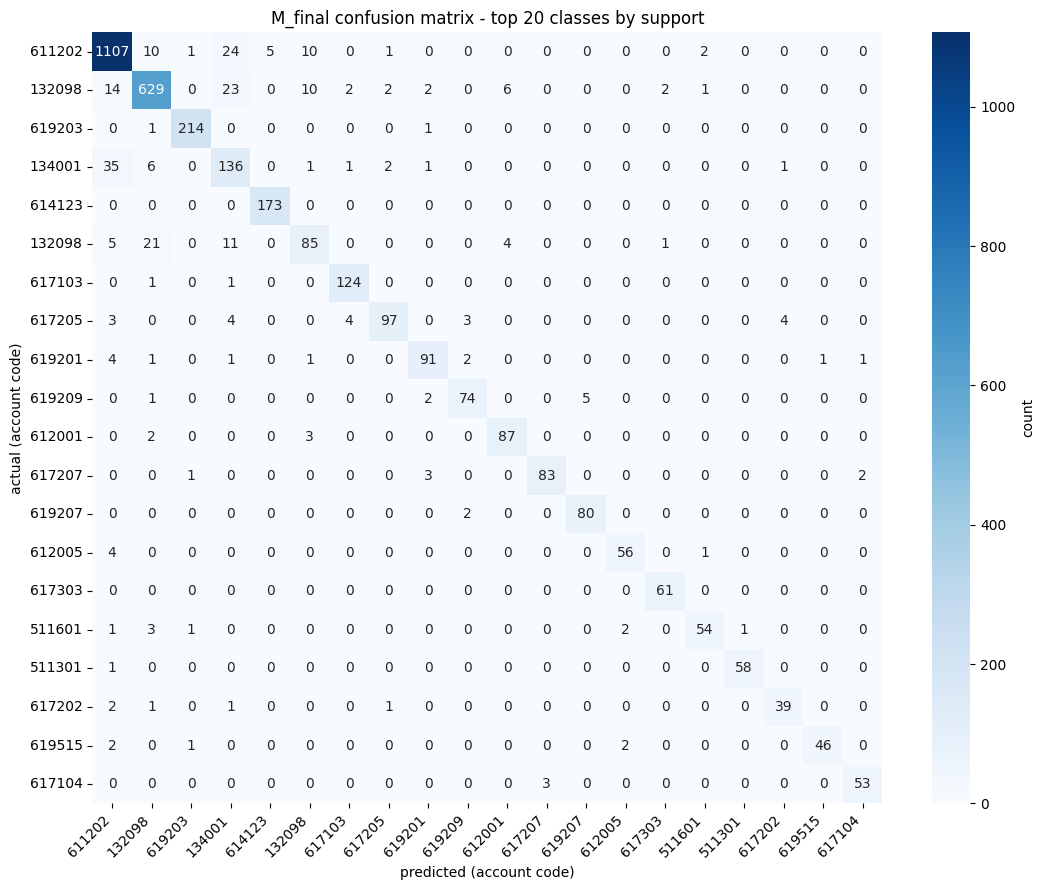

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

top20 = class_counts.head(20).index.tolist()
mask = pd.Series(y).isin(top20).to_numpy()
cm = confusion_matrix(y[mask], y_pred_final[mask], labels=top20)

short_labels = [t.split(" ", 1)[0] for t in top20]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=short_labels,
    yticklabels=short_labels,
    cbar_kws={"label": "count"},
    ax=ax,
)
ax.set_xlabel("predicted (account code)")
ax.set_ylabel("actual (account code)")
ax.set_title("M_final confusion matrix - top 20 classes by support")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Takeaway.** Strong diagonal across the top classes; the brightest off-diagonals are the same economically-adjacent pairs surfaced in §6.2 (e.g. *611202 Online Subscription/Tool* ↔ *134001 Prepaid Operating Expense*).

**Chart 2 — Per-class F1: top 10 vs bottom 10**

Two horizontal bar charts side-by-side. The asymmetry is the story: the head of the distribution is at or near F1 = 1.0; the tail is dominated by classes with support ≤ 4.

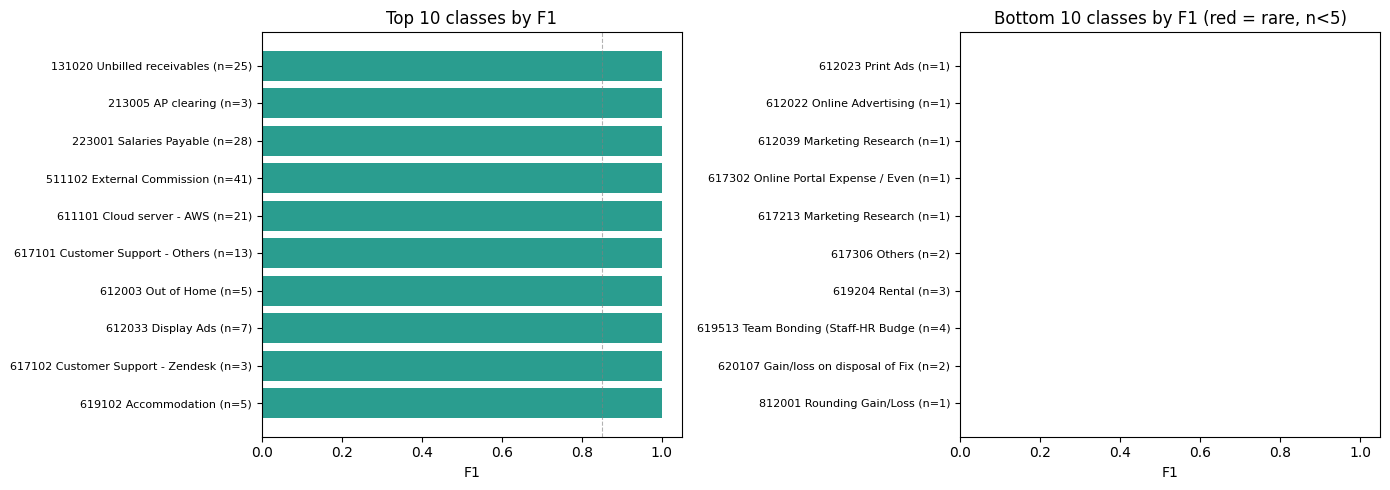

In [36]:
top10 = per_class_df.head(10).iloc[::-1]
bot10 = per_class_df.tail(10).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.barh(range(len(top10)), top10["f1"], color="#2a9d8f")
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f"{c[:35]} (n={s})" for c, s in zip(top10["class"], top10["support"])], fontsize=8)
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1")
ax.set_title("Top 10 classes by F1")
ax.axvline(0.85, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

ax = axes[1]
colors = ["#e63946" if r else "#f4a261" for r in bot10["rare"]]
ax.barh(range(len(bot10)), bot10["f1"], color=colors)
ax.set_yticks(range(len(bot10)))
ax.set_yticklabels([f"{c[:35]} (n={s})" for c, s in zip(bot10["class"], bot10["support"])], fontsize=8)
ax.set_xlim(0, 1.05)
ax.set_xlabel("F1")
ax.set_title("Bottom 10 classes by F1 (red = rare, n<5)")

plt.tight_layout()
plt.show()

**Takeaway.** Every bottom-10 class has support < 5; the model has too few examples to learn them. This is the structural ceiling on macro-F1 and is honestly reported rather than masked.

**Chart 3 — Feature ablation: accuracy drop when each block is removed**

The block whose removal causes the largest drop carries the most signal. This is the visual companion to the §6.3 table.

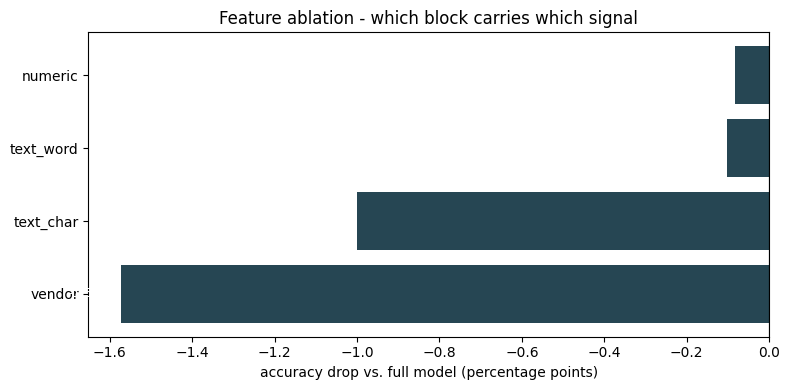

In [37]:
ab = ablation_df[ablation_df["removed_block"] != "(none) full model"].copy()
ab = ab.sort_values("drop_vs_full")
ab["drop_pct"] = ab["drop_vs_full"] * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ab["removed_block"], ab["drop_pct"], color="#264653")
ax.set_xlabel("accuracy drop vs. full model (percentage points)")
ax.set_title("Feature ablation - which block carries which signal")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, ab["drop_pct"]):
    ax.text(val - 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", ha="right", color="white", fontsize=9)
plt.tight_layout()
plt.show()

**Takeaway.** Vendor identity (-1.6 pp) and char_wb n-grams (-1.0 pp) carry the load. Word n-grams and numeric features overlap heavily with the other blocks and contribute less than 0.1 pp each individually — kept for marginal lift and interpretability.